## Fine-tune EfficientNet-B0 on the Cards dataset

I believe this is more then a sufficient setup for initial training. My goal is to improve this later in sagemaker, but it's used as proof-of-concept so I'm not wasting my budget over there. Cheating? No, just using a subscription I'm already paying for :)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -q /content/drive/MyDrive/Blackjack/data.zip -d /content/cards
!ls /content/cards | head

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
data


In [8]:
DATA_ROOT = '/content/cards/data'

## Imports and config
Tried with patience 3- seemed a bit too early because I was getting improvements but not more then best + MIN_DELTA, so I'm giving it a bit more of a fighting chance here

In [16]:
import json, random, time, copy
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE     = 224 #This is how ImageNet does it, EfficientNet-B0 is pretrained on ImageNet so I'm staying consistent
BATCH_SIZE   = 64  #Pretty standard
NUM_WORKERS  = 2
MAX_EPOCHS   = 20
PATIENCE     = 5  #Increased this from 3 to 5, gained longer training (a.k.a. not stopping after 4th epoch...)
MIN_DELTA    = 1e-4 #We don't want tiny improvements to reset our patience count... I'd lose patience if that were the case.

#In TL, the new classifier head is random and needs fast learning, while the pretrained backbone needs to update slowly.
#We don't want to lose valuable knowledge from the backbone.
#PyTorch supports different hyperparameters per parameter group via optimizer = AdamW, check it out here:https://docs.pytorch.org/docs/stable/optim.html
LR_HEAD      = 1e-3
LR_BACKBONE  = 1e-4
WEIGHT_DECAY = 1e-4

OUT = Path('/content/cards-efficientnetb0-v1')
OUT.mkdir(exist_ok=True)
print('device:', DEVICE)

device: cuda


## Datasets and loaders

ImageFolder expects folders named after each class. This matches how the Kaggle zip is laid out.
224px because that’s what the pretrained weights were trained on; resizing first keeps things consistent.
Augmentation is deliberately mild - cards are small objects and too much variation in this context probably isn't going to do us too well...
Horizontal flip only; vertical flip would turn some face cards into nonsense labels.
Workers=2 is enough on Colab

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.RandomRotation(degrees=8),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder(f'{DATA_ROOT}/train', transform=train_tf)
valid_ds = datasets.ImageFolder(f'{DATA_ROOT}/valid', transform=eval_tf)
test_ds  = datasets.ImageFolder(f'{DATA_ROOT}/test',  transform=eval_tf)

CLASSES     = train_ds.classes
NUM_CLASSES = len(CLASSES)
print(f'classes={NUM_CLASSES}  train={len(train_ds)}  valid={len(valid_ds)}  test={len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

classes=52  train=7509  valid=260  test=260


## Model - EfficientNet-B0 pretrained on ImageNet

Starting from ImageNet weights because we don’t have enough data to train conv layers from scratch. Which is okay, I'm trying not to break the bank.
Only the classifier head is random init at the start, everything else starts with sensible filters already.
Split LR: backbone moves slowly, head moves faster. Classic finetune setup, stops the backbone from wrecking good features early.
Cosine schedule is a nice default here; nothing magical, just smooth decay over the max epoch budget.

In [10]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(DEVICE)

head_params     = list(model.classifier.parameters())
backbone_params = [p for n, p in model.named_parameters() if not n.startswith('classifier')]

optim = torch.optim.AdamW(
    [
        {'params': backbone_params, 'lr': LR_BACKBONE},
        {'params': head_params,     'lr': LR_HEAD},
    ],
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=MAX_EPOCHS)
criterion = nn.CrossEntropyLoss()

print(f'total params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 151MB/s]


total params: 4.1M


## Train

Manual loop instead of Trainer. Why? Fewer hidden defaults, easier to tweak when something looks wrong.
Tracking running loss/acc with batch sizes so the curves aren’t lying after variable last batches.
Early stopping on val accuracy with a tiny min_delta - stops wasting GPU time once the metric flatlines.
Always keeping the best val checkpoint, not the last epoch.

My code follows the standard PyTorch training loop pattern shown in official tutorials: [here](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#train-the-network)

I used non_blocking=True which is consistent with PyTorch guidance for overlapping H2D copies with compute when pinned memory / conditions allow: [here](https://docs.pytorch.org/docs/stable/generated/torch.Tensor.to.html)

optim.zero_grad is used as is said to improve performance: [here](https://docs.pytorch.org/docs/stable/generated/torch.optim.Optimizer.zero_grad.html)

Honestly, nothing out of the ordinary, just trying to set a good baseline.


In [17]:
def run_epoch(loader, train=True):
    model.train(train)
    tot_loss, tot_correct, tot = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.inference_mode()
    with ctx:
        for x, y in loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            logits = model(x)
            loss   = criterion(logits, y)
            if train:
                optim.zero_grad(set_to_none=True)
                loss.backward()
                optim.step()
            tot_loss    += loss.item() * x.size(0)
            tot_correct += (logits.argmax(1) == y).sum().item()
            tot         += x.size(0)
    return tot_loss / tot, tot_correct / tot


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val, best_state = -1.0, None
epochs_no_improve = 0
stopped_early = False

t0 = time.time()
for ep in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(valid_loader, train=False)
    scheduler.step()

    for k, v in zip(history.keys(), (tr_loss, tr_acc, vl_loss, vl_acc)):
        history[k].append(v)

    if best_state is None:
        best_val   = vl_acc
        best_state = copy.deepcopy(model.state_dict())
        marker = '  *init*'
        epochs_no_improve = 0
    elif vl_acc > best_val + MIN_DELTA:
        best_val   = vl_acc
        best_state = copy.deepcopy(model.state_dict())
        marker     = '  *best*'
        epochs_no_improve = 0
    else:
        marker = ''
        epochs_no_improve += 1

    print(f'ep {ep:2d}  tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f}  '
          f'vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f}{marker}')

    if epochs_no_improve >= PATIENCE:
        stopped_early = True
        print(f'\nearly stopping: val_acc did not beat best+{MIN_DELTA} for {PATIENCE} epochs (best val_acc={best_val:.4f})')
        break

train_time = time.time() - t0
epochs_ran = len(history['train_loss'])
print(f'\ntrained {epochs_ran} epoch(s) in {train_time/60:.1f} min')
model.load_state_dict(best_state)

ep  1  tr_loss=0.3069 tr_acc=0.9169  vl_loss=0.3703 vl_acc=0.9038  *init*
ep  2  tr_loss=0.2866 tr_acc=0.9218  vl_loss=0.3360 vl_acc=0.8808
ep  3  tr_loss=0.2470 tr_acc=0.9310  vl_loss=0.2950 vl_acc=0.9154  *best*
ep  4  tr_loss=0.2049 tr_acc=0.9417  vl_loss=0.3192 vl_acc=0.8923
ep  5  tr_loss=0.1759 tr_acc=0.9505  vl_loss=0.2510 vl_acc=0.9115
ep  6  tr_loss=0.1464 tr_acc=0.9562  vl_loss=0.2805 vl_acc=0.9308  *best*
ep  7  tr_loss=0.1283 tr_acc=0.9636  vl_loss=0.2203 vl_acc=0.9385  *best*
ep  8  tr_loss=0.1101 tr_acc=0.9660  vl_loss=0.2189 vl_acc=0.9462  *best*
ep  9  tr_loss=0.0864 tr_acc=0.9760  vl_loss=0.2081 vl_acc=0.9423
ep 10  tr_loss=0.0760 tr_acc=0.9804  vl_loss=0.2120 vl_acc=0.9538  *best*
ep 11  tr_loss=0.0540 tr_acc=0.9859  vl_loss=0.1877 vl_acc=0.9577  *best*
ep 12  tr_loss=0.0555 tr_acc=0.9859  vl_loss=0.2023 vl_acc=0.9538
ep 13  tr_loss=0.0512 tr_acc=0.9848  vl_loss=0.1844 vl_acc=0.9538
ep 14  tr_loss=0.0496 tr_acc=0.9873  vl_loss=0.1916 vl_acc=0.9538
ep 15  tr_loss=0.050

<All keys matched successfully>

## Evaluating on the test split

In [18]:
all_logits, all_y = [], []
model.eval()
with torch.inference_mode():
    for x, y in test_loader:
        all_logits.append(model(x.to(DEVICE)).cpu())
        all_y.append(y)
all_logits = torch.cat(all_logits)
all_y      = torch.cat(all_y)
all_pred   = all_logits.argmax(1)

test_acc = (all_pred == all_y).float().mean().item()
print(f'test top-1 accuracy: {test_acc:.4f}\n')

report = classification_report(all_y.numpy(), all_pred.numpy(),
                               target_names=CLASSES, digits=4, output_dict=True)
print(classification_report(all_y.numpy(), all_pred.numpy(),
                            target_names=CLASSES, digits=4))

test top-1 accuracy: 0.9038

                   precision    recall  f1-score   support

     ace of clubs     1.0000    1.0000    1.0000         5
  ace of diamonds     1.0000    1.0000    1.0000         5
    ace of hearts     1.0000    1.0000    1.0000         5
    ace of spades     1.0000    1.0000    1.0000         5
   eight of clubs     0.8333    1.0000    0.9091         5
eight of diamonds     1.0000    1.0000    1.0000         5
  eight of hearts     0.8333    1.0000    0.9091         5
  eight of spades     1.0000    0.8000    0.8889         5
    five of clubs     1.0000    0.8000    0.8889         5
 five of diamonds     1.0000    0.8000    0.8889         5
   five of hearts     1.0000    1.0000    1.0000         5
   five of spades     1.0000    1.0000    1.0000         5
    four of clubs     1.0000    1.0000    1.0000         5
 four of diamonds     1.0000    1.0000    1.0000         5
   four of hearts     1.0000    1.0000    1.0000         5
   four of spades     1.00

## Figures for the report

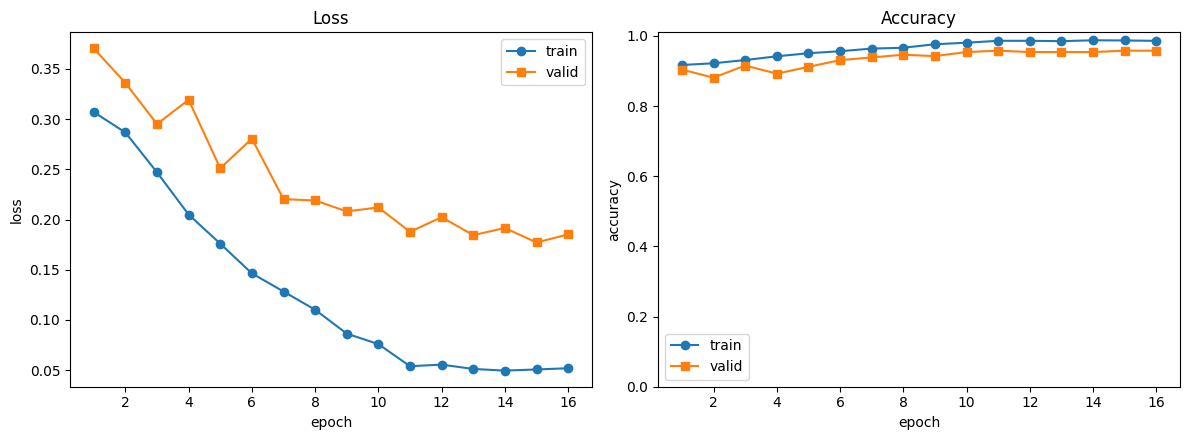

In [20]:
ep_x = list(range(1, len(history['train_loss']) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(ep_x, history['train_loss'], marker='o', label='train')
ax1.plot(ep_x, history['val_loss'],   marker='s', label='valid')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.set_title('Loss'); ax1.legend()

ax2.plot(ep_x, history['train_acc'], marker='o', label='train')
ax2.plot(ep_x, history['val_acc'],   marker='s', label='valid')
ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy'); ax2.set_ylim(0, 1.01)
ax2.set_title('Accuracy'); ax2.legend()

fig.tight_layout()
fig.savefig(OUT / 'training_curves.png', dpi=150)
plt.show()

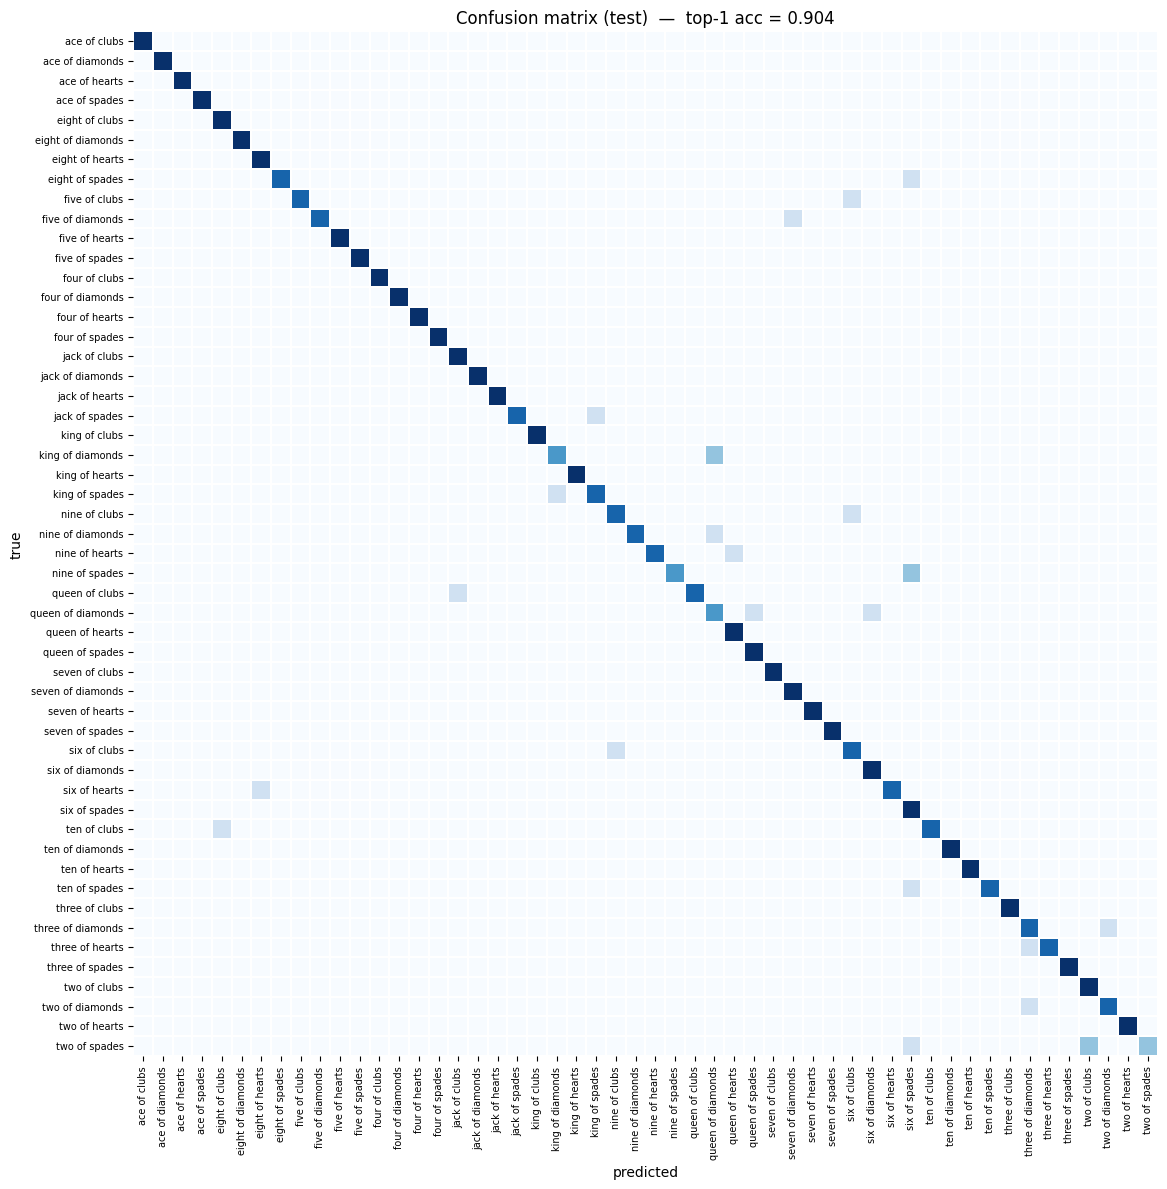

top confusions (true -> predicted):
    2   two of spades             -> two of clubs
    2   nine of spades            -> six of spades
    2   king of diamonds          -> queen of diamonds
    1   two of spades             -> six of spades
    1   two of diamonds           -> three of diamonds
    1   three of hearts           -> three of diamonds
    1   three of diamonds         -> two of diamonds
    1   ten of spades             -> six of spades
    1   ten of clubs              -> eight of clubs
    1   six of hearts             -> eight of hearts


In [21]:
cm = confusion_matrix(all_y.numpy(), all_pred.numpy())
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues', cbar=False, xticklabels=CLASSES, yticklabels=CLASSES,
            square=True, linewidths=0.1, ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title(f'Confusion matrix (test)  —  top-1 acc = {test_acc:.3f}')
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
fig.tight_layout()
fig.savefig(OUT / 'confusion_matrix.png', dpi=150)
plt.show()

off = cm.copy()
np.fill_diagonal(off, 0)
flat = [(off[i, j], CLASSES[i], CLASSES[j]) for i in range(len(CLASSES)) for j in range(len(CLASSES))]
flat.sort(reverse=True)
print('top confusions (true -> predicted):')
for n, t, p in flat[:10]:
    if n == 0: break
    print(f'  {n:3d}   {t:25s} -> {p}')

##Saving artefacts and package for S3

In [22]:
torch.save(model.state_dict(), OUT / 'model.pt')

with open(OUT / 'classes.json', 'w') as f:
    json.dump(CLASSES, f, indent=2)

with open(OUT / 'metadata.json', 'w') as f:
    json.dump({
        'model':         'efficientnet_b0',
        'num_classes':   NUM_CLASSES,
        'img_size':      IMG_SIZE,
        'max_epochs':    MAX_EPOCHS,
        'epochs_ran':    epochs_ran,
        'early_stopped': stopped_early,
        'patience':      PATIENCE,
        'min_delta':     MIN_DELTA,
        'best_val_acc':  best_val,
        'batch_size':    BATCH_SIZE,
        'lr_backbone':   LR_BACKBONE,
        'lr_head':       LR_HEAD,
        'weight_decay':  WEIGHT_DECAY,
        'seed':          SEED,
        'train_seconds': train_time,
        'test_top1_acc': test_acc,
        'device':        torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu',
        'imagenet_mean': IMAGENET_MEAN,
        'imagenet_std':  IMAGENET_STD,
    }, f, indent=2)

with open(OUT / 'classification_report.json', 'w') as f:
    json.dump(report, f, indent=2)

import tarfile
tar_path = OUT / 'model.tar.gz'
with tarfile.open(tar_path, 'w:gz') as tar:
    tar.add(OUT / 'model.pt',      arcname='model.pt')
    tar.add(OUT / 'classes.json',  arcname='classes.json')
    tar.add(OUT / 'metadata.json', arcname='metadata.json')

print(tar_path, f'{tar_path.stat().st_size/1e6:.1f} MB')
!ls -la {OUT}

/content/cards-efficientnetb0-v1/model.tar.gz 15.3 MB
total 31468
drwxr-xr-x 2 root root     4096 Apr 21 18:42 .
drwxr-xr-x 1 root root     4096 Apr 21 17:45 ..
-rw-r--r-- 1 root root     1055 Apr 21 18:42 classes.json
-rw-r--r-- 1 root root     6494 Apr 21 18:42 classification_report.json
-rw-r--r-- 1 root root   221998 Apr 21 18:39 confusion_matrix.png
-rw-r--r-- 1 root root      408 Apr 21 18:42 metadata.json
-rw-r--r-- 1 root root 16576275 Apr 21 18:42 model.pt
-rw-r--r-- 1 root root 15319276 Apr 21 18:42 model.tar.gz
-rw-r--r-- 1 root root    72549 Apr 21 18:37 training_curves.png


In [23]:
from google.colab import files

files.download(str(tar_path))
files.download(str(OUT / 'training_curves.png'))
files.download(str(OUT / 'confusion_matrix.png'))
files.download(str(OUT / 'metadata.json'))
files.download(str(OUT / 'classification_report.json'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>